<img src="https://cmse.msu.edu/_assets/images/about/image001.png"
     alt="CMSE Logo"
     align="right" 
     height="400" 
     width="400" />
# <font color=18453B>CMSE 801 - Day 17</font>
## Accessing information in and manipulating 2D NumPy arrays
### March 17, 2026

## General Course Announcements

* Homework 4 will come out later this week. Dr. Yan'll send an email out once it's available.
    * It will be due **Saturday, April 4, by 11:59pm**.
* Working on reviewing your project proposal submissions. Dr. Yan will provide feedbacks to your submitted document in D2L.
    * You're encouraged to get started on your project!

## Questions/comments from Day 17 PCA

* How do 2D NumPy arrays differ from Pandas dataframes?
* What does "shape" mean in the context of an image? (and other comments related to the image section)
* Correctly indexing 2D arrays can get tricky.
* Some issues with masking data to get only the values desired when using a 2D array.


## How is an image stored in Python using NumPy?

At each pixel location in a 2D image, we can think of there as being 3 values associated with that pixel.

<img src="https://cdn.filestackcontent.com/jvbsG1EPRXWFGnoPxB0G" width=1000>

## So then how do we store these three values at each location?

We can either use a 3D NumPy array, which would have a **shape** of:

$N_{\textrm{pixels_high}} \times N_{\textrm{pixels_wide}} \times 3$ **or** $N_{\textrm{rows}} \times N_{\textrm{columns}} \times 3$

Or, we could split them into three separate 2D NumPy arrays, one for each color.

<img src="https://ggcarvalho.dev/img/posts/image_proc/rgbrep.png" width=300>

## Looking back at the example in the notebook
    

In [1]:
from PIL import Image
# Load the image
picture = Image.open("example.jpeg")

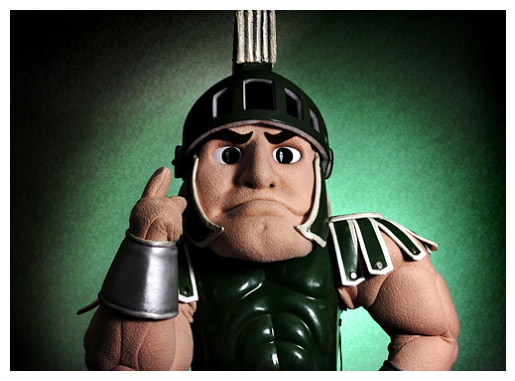

In [2]:
import matplotlib.pyplot as plt
plt.imshow(picture)
plt.axis('off');

### So now we can split it up!

In [3]:
import numpy as np

#Convert to an array
img_array = np.asarray(picture)
picture_array = img_array.copy() ##We have to make a copy of the array so as to not overwrite the original image
print("The shape is:", picture_array.shape)

##Split the red, blue, and green components for each of the pixels in our image into three new arrays
red_array, green_array, blue_array = picture_array[:,:,0], picture_array[:,:,1], picture_array[:,:,2]

The shape is: (364, 500, 3)


### And we can visualize just one of them!

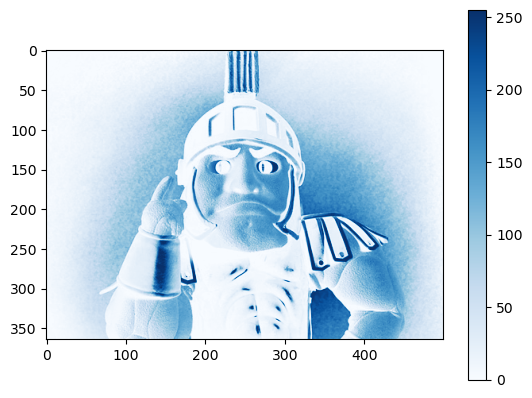

In [12]:
##Let's plot each channel and see what it looks like
plt.imshow(blue_array,cmap="Blues")
plt.colorbar();

## Now let's explore a bit how we can access data in NumPy arrays and compare to Pandas

In [13]:
import pandas as pd

cars_pandas = pd.read_csv("cars.csv")
cars_pandas.head()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
0,2011,335,6,2,26,19,3916,46135
1,2011,300,6,2,28,19,3916,40650
2,2011,300,6,2,28,20,3916,36350
3,2011,230,6,2,28,18,3916,29450
4,2011,230,6,2,28,18,3916,34500


#### What if we want to look at just the highway MPG?

In [14]:
# We can use the column name
cars_pandas['highway MPG']

0        26
1        28
2        28
3        28
4        28
         ..
11809    23
11810    23
11811    23
11812    23
11813    26
Name: highway MPG, Length: 11814, dtype: int64

In [15]:
# but this also works
cars_pandas.iloc[:,4]

0        26
1        28
2        28
3        28
4        28
         ..
11809    23
11810    23
11811    23
11812    23
11813    26
Name: highway MPG, Length: 11814, dtype: int64

#### This means we could access the information similarly if it were in a NumPy array!

In [16]:
##First, load in the dataset WITH NUMPY
car_header = np.loadtxt("cars.csv", delimiter=",", dtype=str, max_rows=1)
car_data = np.loadtxt("cars.csv", delimiter=",", dtype=int, skiprows=1)
# display the first 5 rows
print(car_data[:5])

[[ 2011   335     6     2    26    19  3916 46135]
 [ 2011   300     6     2    28    19  3916 40650]
 [ 2011   300     6     2    28    20  3916 36350]
 [ 2011   230     6     2    28    18  3916 29450]
 [ 2011   230     6     2    28    18  3916 34500]]


In [17]:
# compare to pandas
cars_pandas.head()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
0,2011,335,6,2,26,19,3916,46135
1,2011,300,6,2,28,19,3916,40650
2,2011,300,6,2,28,20,3916,36350
3,2011,230,6,2,28,18,3916,29450
4,2011,230,6,2,28,18,3916,34500


#### So let's look at the highway MPG again

In [18]:
print(car_data[:, 4])

[26 28 28 ... 23 23 26]


In [19]:
# compare to pandas
cars_pandas.iloc[:,4]

0        26
1        28
2        28
3        28
4        28
         ..
11809    23
11810    23
11811    23
11812    23
11813    26
Name: highway MPG, Length: 11814, dtype: int64

#### And so, if we can access data in a similar way, we can build masks in a similar way

Let's look at cars with over 30 MPG on the highway

In [20]:
over_30_mpg = car_data[car_data[:, 4] >= 30]

# Look at the first 5
print(over_30_mpg[:5])

[[ 2017   160     4     2    35    26   819 27495]
 [ 2017   160     4     2    35    26   819 24995]
 [ 2017   160     4     2    35    26   819 28195]
 [ 2016   240     4     2    35    23  3916 32850]
 [ 2016   240     4     2    34    23  3916 38650]]


In [21]:
# And now let's average the cost for these cars
print("Average cost for cars that get over 30 MPG on the highway:",round(np.mean(over_30_mpg[:, 7]),2))

Average cost for cars that get over 30 MPG on the highway: 26386.24


## Goals for today
* Practice accessing information in 2D NumPy arrays. We'll be working with image data to practice this.
* Use your ability to access information in NumPy arrays to design an algorithm or perform a calculation to complete a specific task based on the data
* The tools you build today will be valuable for building what we call "Agent-based Models", which is what we'll do next week.

## Looking forward - Day 18 PCA: A intro to agent-based models (ABMs)

* Explore what an agent-based model is and how it can be used
* Practice manipulating 2D arrays to use with such models.